<a href="https://colab.research.google.com/github/Roshni-AngelAlex/MACHINE-LEARNING-LAB-24ADI003-/blob/main/MLLABEX7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**MACHINE LEARNING**

**LAB EXPERIMENT 7**

**Clustering using K-Means and Gaussian Mixture Models (GMM)**

**NAME : ROSHNI ANGEL A / ROLLNO: 24BAD101**

SCENARIO 1 – CLUSTERING USING K-MEANS

Problem Statement

Group customers/data points into clusters based on similarity using K-Means clustering.


Dataset (Kaggle – Public)
Mall Customer Segmentation Dataset

Dataset Link: https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python


Target Variable:

Cluster labels

(no predefined labels – unsupervised learning)

Input Feature:

• Annual Income

• Spending Score

• Age (optional)


Saving Mall_Customers.csv to Mall_Customers (1).csv
First Five Rows of Dataset
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes

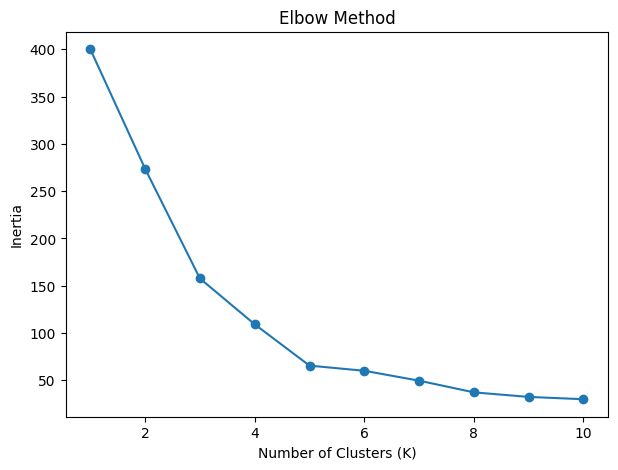


Dataset with Cluster Labels
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   Cluster  
0        4  
1        2  
2        4  
3        2  
4        4  


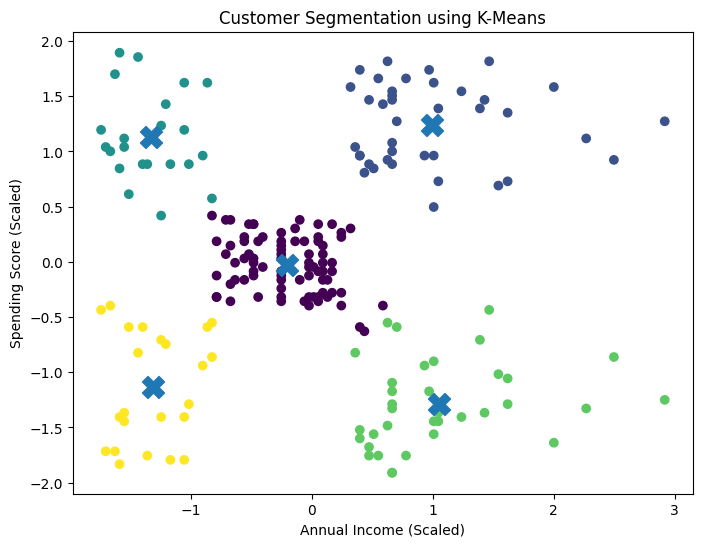


Cluster Centroids (Scaled Values)
[[-0.20091257 -0.02645617]
 [ 0.99158305  1.23950275]
 [-1.32954532  1.13217788]
 [ 1.05500302 -1.28443907]
 [-1.30751869 -1.13696536]]

Inertia (WCSS): 65.56840815571681
Silhouette Score: 0.5546571631111091

Cluster Characteristics
         Annual Income (k$)  Spending Score (1-100)
Cluster                                            
0                 55.296296               49.518519
1                 86.538462               82.128205
2                 25.727273               79.363636
3                 88.200000               17.114286
4                 26.304348               20.913043


In [1]:
# EXPT NO: 7
# Clustering using K-Means – Mall Customer Segmentation

# Step 1: Upload Dataset
from google.colab import files
uploaded = files.upload()

# Step 2: Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Step 3: Load Dataset
df = pd.read_csv("Mall_Customers.csv")

print("First Five Rows of Dataset")
print(df.head())

print("\nDataset Information")
df.info()

print("\nStatistical Summary")
print(df.describe())

# Step 4: Data Preprocessing
print("\nChecking Missing Values")
print(df.isnull().sum())

df = df.dropna()

# Step 5: Select Relevant Features
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Step 6: Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 7: Use Elbow Method to Determine Optimal K
inertia = []

for k in range(1, 11):
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X_scaled)
    inertia.append(model.inertia_)

plt.figure(figsize=(7,5))
plt.plot(range(1,11), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.show()

# Step 8: Apply K-Means Clustering
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# Step 9: Assign Cluster Labels
df['Cluster'] = clusters

print("\nDataset with Cluster Labels")
print(df.head())

# Step 10: Visualize Clusters
plt.figure(figsize=(8,6))
plt.scatter(
    X_scaled[:,0],
    X_scaled[:,1],
    c=clusters,
    cmap='viridis'
)

plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    s=250,
    marker='X'
)

plt.title("Customer Segmentation using K-Means")
plt.xlabel("Annual Income (Scaled)")
plt.ylabel("Spending Score (Scaled)")
plt.show()

# Step 11: Display Cluster Centroids
print("\nCluster Centroids (Scaled Values)")
print(kmeans.cluster_centers_)

# Step 12: Evaluation Metrics
print("\nInertia (WCSS):", kmeans.inertia_)

sil_score = silhouette_score(X_scaled, clusters)
print("Silhouette Score:", sil_score)

# Step 13: Interpret Cluster Characteristics
cluster_summary = df.groupby('Cluster')[[
    'Annual Income (k$)',
    'Spending Score (1-100)'
]].mean()

print("\nCluster Characteristics")
print(cluster_summary)

SCENARIO 2 – CLUSTERING USING GMM

Problem Statement
Cluster data using Gaussian Mixture Models to capture probabilistic cluster membership.

Dataset (Kaggle – Public) Mall Customer Segmentation Dataset

Dataset Link: https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python

Target Variable: Cluster probabilities and labels

Input Features

• Annual Income

• Spending Score

• Age (optional)


Saving Mall_Customers.csv to Mall_Customers (2).csv
First Five Rows
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4),

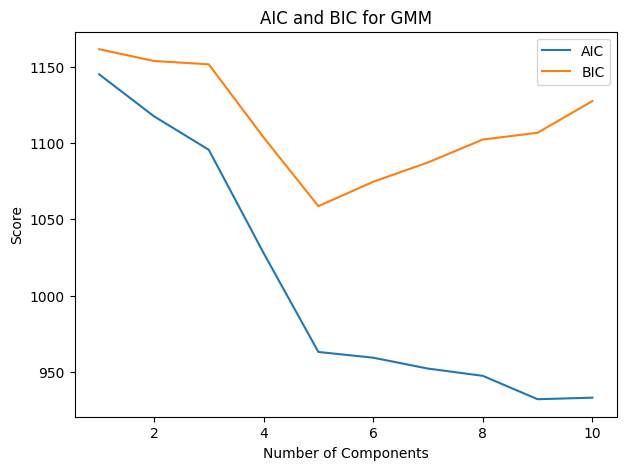


Cluster Membership Probabilities (First 5 Rows)
[[1.57689698e-05 1.88009163e-08 9.52031247e-04 5.20013085e-08
  9.99032129e-01]
 [1.62776204e-05 1.89596786e-04 9.99790184e-01 4.21013390e-23
  3.94154449e-06]
 [2.21339374e-19 9.52615737e-19 1.22549539e-12 1.86223280e-04
  9.99813777e-01]
 [1.05444778e-04 1.80087695e-04 9.99693745e-01 3.79390067e-21
  2.07229768e-05]
 [6.47301428e-05 3.84273231e-08 1.55669540e-03 4.75722704e-08
  9.98378488e-01]]

Log-Likelihood: -2.262502621973241
AIC: 963.0010487892964
BIC: 1058.6522524191894
Silhouette Score (GMM): 0.5536892843811245


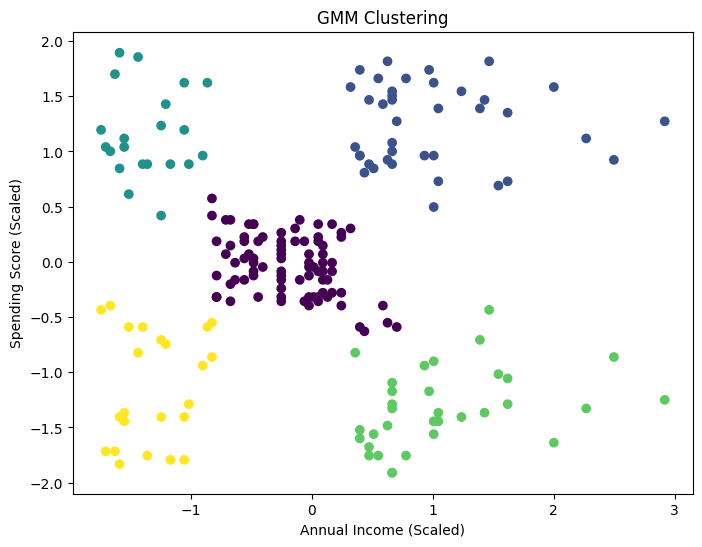

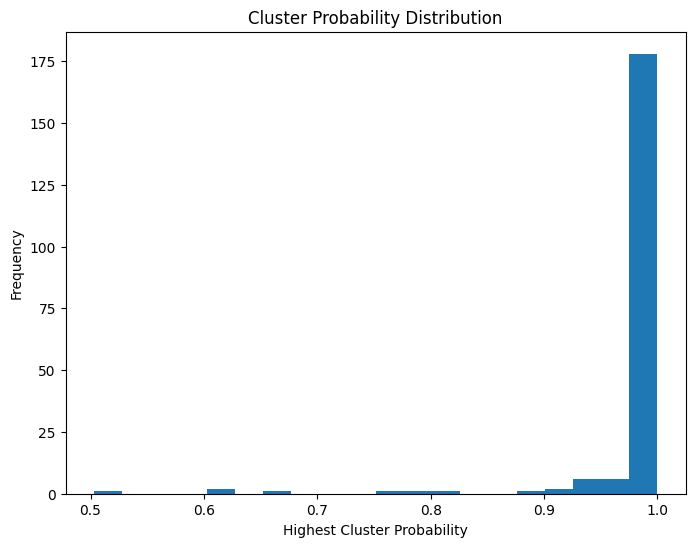

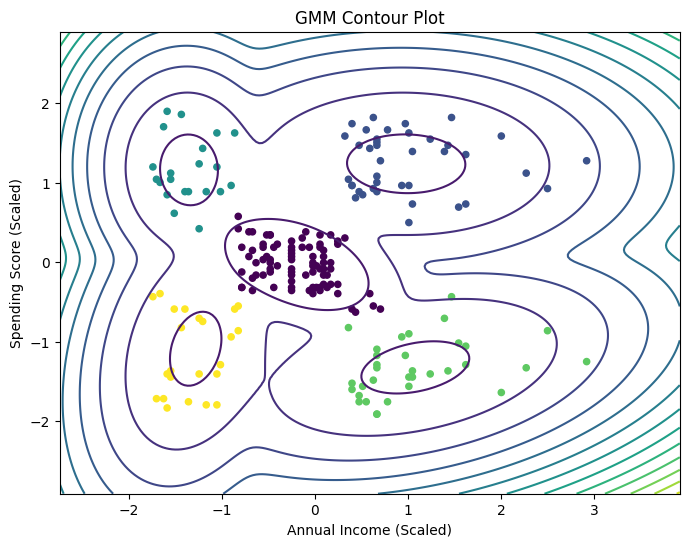

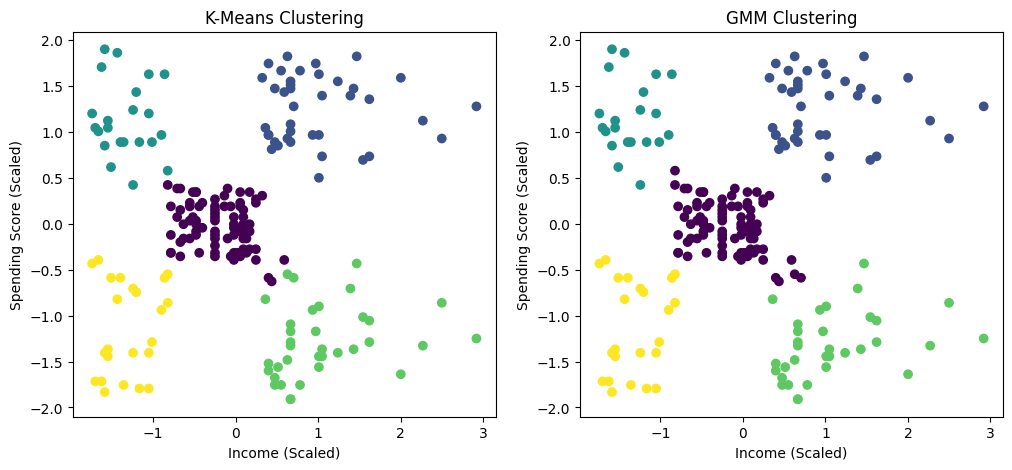


GMM Cluster Characteristics
             Annual Income (k$)  Spending Score (1-100)
GMM_Cluster                                            
0                     55.642857               49.369048
1                     86.538462               82.128205
2                     25.095238               80.047619
3                     88.818182               16.000000
4                     26.304348               20.913043


In [2]:
# EXPT NO: 7
# Clustering using Gaussian Mixture Model (GMM)

# Step 1: Upload Dataset
from google.colab import files
uploaded = files.upload()

# Step 2: Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Step 3: Load Dataset
df = pd.read_csv("Mall_Customers.csv")

print("First Five Rows")
print(df.head())

print("\nDataset Information")
df.info()

# Step 4: Data Preprocessing
print("\nMissing Values")
print(df.isnull().sum())

df = df.dropna()

# Step 5: Select Features
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Step 6: Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 7: Choose Number of Components using AIC and BIC
aic_values = []
bic_values = []
components_range = range(1,11)

for n in components_range:
    gmm_temp = GaussianMixture(n_components=n, random_state=42)
    gmm_temp.fit(X_scaled)
    aic_values.append(gmm_temp.aic(X_scaled))
    bic_values.append(gmm_temp.bic(X_scaled))

plt.figure(figsize=(7,5))
plt.plot(components_range, aic_values, label="AIC")
plt.plot(components_range, bic_values, label="BIC")
plt.xlabel("Number of Components")
plt.ylabel("Score")
plt.title("AIC and BIC for GMM")
plt.legend()
plt.show()

# Step 8: Apply Gaussian Mixture Model
gmm = GaussianMixture(n_components=5, random_state=42)
gmm.fit(X_scaled)

# Step 9: Predict Cluster Probabilities
probabilities = gmm.predict_proba(X_scaled)

print("\nCluster Membership Probabilities (First 5 Rows)")
print(probabilities[:5])

# Step 10: Assign Cluster Labels
gmm_clusters = gmm.predict(X_scaled)
df['GMM_Cluster'] = gmm_clusters

# Step 11: Evaluation Metrics
log_likelihood = gmm.score(X_scaled)
print("\nLog-Likelihood:", log_likelihood)

print("AIC:", gmm.aic(X_scaled))
print("BIC:", gmm.bic(X_scaled))

sil_score_gmm = silhouette_score(X_scaled, gmm_clusters)
print("Silhouette Score (GMM):", sil_score_gmm)

# Step 12: Visualization of GMM Clusters
plt.figure(figsize=(8,6))
plt.scatter(
    X_scaled[:,0],
    X_scaled[:,1],
    c=gmm_clusters,
    cmap='viridis'
)
plt.title("GMM Clustering")
plt.xlabel("Annual Income (Scaled)")
plt.ylabel("Spending Score (Scaled)")
plt.show()

# Step 13: Cluster Probability Distribution
plt.figure(figsize=(8,6))
plt.hist(probabilities.max(axis=1), bins=20)
plt.title("Cluster Probability Distribution")
plt.xlabel("Highest Cluster Probability")
plt.ylabel("Frequency")
plt.show()

# Step 14: GMM Contour Plot
x = np.linspace(X_scaled[:,0].min()-1, X_scaled[:,0].max()+1, 200)
y = np.linspace(X_scaled[:,1].min()-1, X_scaled[:,1].max()+1, 200)
X_grid, Y_grid = np.meshgrid(x, y)
XX = np.array([X_grid.ravel(), Y_grid.ravel()]).T

Z = -gmm.score_samples(XX)
Z = Z.reshape(X_grid.shape)

plt.figure(figsize=(8,6))
plt.contour(X_grid, Y_grid, Z, levels=15)
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=gmm_clusters, cmap='viridis', s=20)
plt.title("GMM Contour Plot")
plt.xlabel("Annual Income (Scaled)")
plt.ylabel("Spending Score (Scaled)")
plt.show()

# Step 15: Comparison with K-Means
kmeans = KMeans(n_clusters=5, random_state=42)
kmeans_clusters = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=kmeans_clusters, cmap='viridis')
plt.title("K-Means Clustering")
plt.xlabel("Income (Scaled)")
plt.ylabel("Spending Score (Scaled)")

plt.subplot(1,2,2)
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=gmm_clusters, cmap='viridis')
plt.title("GMM Clustering")
plt.xlabel("Income (Scaled)")
plt.ylabel("Spending Score (Scaled)")

plt.show()

# Step 16: Cluster Interpretation
cluster_summary = df.groupby('GMM_Cluster')[[
    'Annual Income (k$)',
    'Spending Score (1-100)'
]].mean()

print("\nGMM Cluster Characteristics")
print(cluster_summary)